# OLP Recall 0.30 진단 — 레이어별 쌍 분리 (가설 A vs B)

**목표 (10차 미팅 §②).** `Oral_Diseases` 7-class linear-eval에서 **OLP recall이 0.30에 고정**(10개 중 3개)이고
Linear·LoRA·Full FT **모든 방법에서 동일**하다. 두 가설을 가른다:

- **가설 A** — frozen PanDerm 특징공간이 OLP를 혼동클래스와 **구조적으로 분리 못 함**(표현 한계).
- **가설 B** — 특징엔 정보가 있는데 **분류 경계만 잘못** 그어짐(수정 가능).

**핵심 방법 — n=10 test에 의존하지 않는 진단.** OLP test는 10개뿐이라 지표가 0.1 스텝으로 요동친다. 그래서
분리도는 **pooled train+val(OLP 84장) 특징에 교차검증(CV)** 으로 측정한다. 이 진단이 B면 "frozen 특징은 분리 가능"
이므로 Full FT 실패는 표현 한계가 아니라 **최적화/과적합**으로 확정된다(= Full FT 과적합 배제).

**확정 사실.** OLP 오분류 누수 OT 3·OC 2·MC 1·Gum 1 (precision 0.75). OLP은 **train 최다 클래스(74)** 인데 test recall 최악
→ 데이터 부족이 아닌 경계/특징중첩 문제. pooled train+val: OLP 84·MC 81·OT 57·Gum 54·OC 48.

**산출물** → `PanDerm/output_dir/oral_diseases_olp_separability/`:
`olp_layerwise_cls.npz`, `pairwise_separability_linear.csv`, `pairwise_separability_nonlinear.csv`,
`overlap_metrics.csv`, `separability_curves.png`, `verdict_heatmap.png`, **`olp_separability_verdict.csv`**(→ Notebook B).

In [1]:
import os, sys, io, time, contextlib, warnings
import numpy as np, pandas as pd, torch
warnings.filterwarnings("ignore")
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from IPython.display import Image, display

# --- robust paths (avoid the /wksp/ hardcode from the reference notebook) ---
PROJECT_ROOT = (os.path.abspath(os.path.join(os.getcwd(), "../../..")))
assert os.path.isdir(os.path.join(PROJECT_ROOT, "PanDerm")), f"unexpected root: {PROJECT_ROOT}"
CLS_DIR = os.path.join(PROJECT_ROOT, "PanDerm", "classification")
sys.path.insert(0, CLS_DIR)
os.chdir(CLS_DIR)                       # match linear_eval.py working dir (model registry / relative paths)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEPTH, EMBED_DIM = 24, 1024
CHECKPOINT = os.path.join(PROJECT_ROOT, "PanDerm/checkpoint/panderm_ll_data6_checkpoint-499.pth")
CSV     = os.path.join(PROJECT_ROOT, "PanDerm/data/Oral_Diseases/Linear Evaluation/oral_diseases_multiclass.csv")
IMG_ROOT= os.path.join(PROJECT_ROOT, "PanDerm/data/Oral_Diseases") + "/"
PRED_CSV= os.path.join(PROJECT_ROOT, "PanDerm/output_dir/oral_diseases_panderm_large_lp/oral_diseases_multiclass.csv")
OUT     = os.path.join(PROJECT_ROOT, "PanDerm/output_dir/oral_diseases_olp_separability")
CACHE   = os.path.join(OUT, "layerwise_cls_cache")
os.makedirs(CACHE, exist_ok=True)

CLASS_NAMES = ["CaS", "CoS", "Gum", "MC", "OC", "OLP", "OT"]
IDX = {n: i for i, n in enumerate(CLASS_NAMES)}
OLP = IDX["OLP"]
# confuser pairs ordered by leak weight + OLP-vs-rest
PAIRS = [("OLP_vs_OT", ["OT"]), ("OLP_vs_OC", ["OC"]), ("OLP_vs_MC", ["MC"]),
         ("OLP_vs_Gum", ["Gum"]), ("OLP_vs_rest", ["CaS", "CoS", "Gum", "MC", "OC", "OT"])]
LEAK_W = {"OLP_vs_OT": 3, "OLP_vs_OC": 2, "OLP_vs_MC": 1, "OLP_vs_Gum": 1}
BATCH_SIZE, NUM_WORKERS = 32, 2
# Okabe-Ito CVD-safe palette
OI = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#000000", "#56B4E9", "#D55E00"]
print("root:", PROJECT_ROOT, "| device:", DEVICE)

root: /home/junkim/paper_ajou_dev | device: cuda


## Stage 0 · Confusion 정리 — 타깃 혼동쌍 확정

디스크에 저장된 baseline 예측(`oral_diseases_panderm_large_lp/oral_diseases_multiclass.csv`)에서 OLP 오분류
누수 경로를 재구성한다. 이미 알려진 값(OT·OC 지배)을 자체적으로 재확인하고, 이후 Stage의 타깃 쌍을 고정한다.

In [2]:
pred = pd.read_csv(PRED_CSV)
olp = pred[pred.true_label == OLP]
n_olp = len(olp); correct = int((olp.predicted_label == OLP).sum())
leak = (olp[olp.predicted_label != OLP]["predicted_label"]
        .map(lambda i: CLASS_NAMES[int(i)]).value_counts())
# precision: FP into OLP
fp = int(((pred.true_label != OLP) & (pred.predicted_label == OLP)).sum())
prec = correct / (correct + fp) if (correct + fp) else float("nan")
print(f"OLP test recall = {correct}/{n_olp} = {correct/n_olp:.2f} | precision = {prec:.2f} (FP={fp})")
print("OLP misclassification leak (True OLP -> Pred):")
print(leak.to_string())
TARGET_PAIRS = [p for p, _ in PAIRS]
print("\nTARGET_PAIRS (leak-ordered):", TARGET_PAIRS)

OLP test recall = 3/10 = 0.30 | precision = 0.75 (FP=1)
OLP misclassification leak (True OLP -> Pred):
predicted_label
OT     3
OC     2
MC     1
Gum    1

TARGET_PAIRS (leak-ordered): ['OLP_vs_OT', 'OLP_vs_OC', 'OLP_vs_MC', 'OLP_vs_Gum', 'OLP_vs_rest']


## Stage 1 · 24-블록 CLS 특징 추출 (frozen, 학습 파라미터 0)

각 블록에 forward hook 을 걸어 `out[:,0]`(CLS, `self.norm` **이전**)을 캡처하고, 같은 forward 의 반환값으로
post-norm 마지막 CLS(=문서화 baseline feature)도 얻는다. **fp32 고정**(공분산/Bhattacharyya 수치안정). 최초 1회만
추출 후 캐시. **sanity**: `‖LayerNorm(prenorm_L23) − postnorm_last‖_∞ ≈ 0` — 캐시가 baseline 특징 경로를 재현함을 증명.

In [3]:
import argparse
with contextlib.redirect_stdout(io.StringIO()):        # suppress get_encoder's model dump
    from models import get_encoder
    from datasets.derm_data import Derm_Dataset
    model, eval_transform = get_encoder(argparse.Namespace(pretrained_checkpoint=CHECKPOINT,
                                                           model="PanDerm_Large_LP"), "PanDerm_Large_LP")
model.eval().to(DEVICE)
for p in model.parameters():
    p.requires_grad_(False)
assert len(model.blocks) == DEPTH and model.embed_dim == EMBED_DIM
assert sum(p.numel() for p in model.parameters() if p.requires_grad) == 0, "must be a pure frozen extractor"

def extract_split(df, split):
    dset = Derm_Dataset(df=df, root=IMG_ROOT, transforms=eval_transform, **{split: True})
    loader = torch.utils.data.DataLoader(dset, batch_size=BATCH_SIZE, shuffle=False,
                                         num_workers=NUM_WORKERS, pin_memory=True)
    buf = {i: [] for i in range(DEPTH)}
    def make_hook(i):
        def hook(_m, _in, out):                        # out: (B,197,1024) pre-self.norm
            buf[i].append(out[:, 0].detach().float().cpu())   # CLS only, fp32
        return hook
    handles = [model.blocks[i].register_forward_hook(make_hook(i)) for i in range(DEPTH)]
    post, labels, filenames = [], [], []
    try:
        for x, y, fn in loader:
            with torch.inference_mode():
                out = model.forward_features(x.to(DEVICE), is_train=False)   # (B,1024) post-norm last CLS
            post.append(out.detach().float().cpu()); labels.append(torch.as_tensor(y)); filenames.extend(list(fn))
    finally:
        for h in handles:
            h.remove()
    pre = np.stack([torch.cat(buf[i]).numpy() for i in range(DEPTH)], axis=1).astype(np.float32)
    return pre, torch.cat(post).numpy().astype(np.float32), torch.cat(labels).numpy().astype(np.int64), \
           np.array(filenames, dtype=object)

df = pd.read_csv(CSV)
for split in ["train", "val", "test"]:
    if os.path.exists(os.path.join(CACHE, f"{split}_cls_prenorm.npy")):
        print(f"[{split}] cached"); continue
    t0 = time.time(); pre, post, lab, fn = extract_split(df, split)
    for name, arr in [("cls_prenorm", pre), ("cls_postnorm_last", post), ("labels", lab), ("filenames", fn)]:
        np.save(os.path.join(CACHE, f"{split}_{name}.npy"), arr)
    print(f"[{split}] pre{pre.shape} post{post.shape} {time.time()-t0:.0f}s "
          f"counts={ {CLASS_NAMES[c]: int((lab==c).sum()) for c in range(7)} }")

Ld = lambda s, n: np.load(os.path.join(CACHE, f"{s}_{n}.npy"), allow_pickle=True)
# consolidated single-file cache
np.savez(os.path.join(OUT, "olp_layerwise_cls.npz"),
         **{f"{k}_{s}": Ld(s, k) for s in ["train", "val", "test"]
            for k in ["cls_prenorm", "cls_postnorm_last", "labels", "filenames"]})

# sanity: LayerNorm(prenorm L23) == postnorm last CLS
pre23 = Ld("train", "cls_prenorm")[:16, DEPTH-1, :]; post16 = Ld("train", "cls_postnorm_last")[:16]
with torch.inference_mode():
    dinf = float(np.abs(model.norm(torch.tensor(pre23).to(DEVICE)).cpu().numpy() - post16).max())
assert dinf < 1e-4, f"sanity failed: {dinf}"
print(f"SANITY ||norm(prenorm_L23)-postnorm||_inf = {dinf:.2e}  (== documented baseline feature path)")

# pooled train+val (the CV substrate; test held out entirely)
pre = np.concatenate([Ld("train", "cls_prenorm"), Ld("val", "cls_prenorm")], axis=0)
y_all = np.concatenate([Ld("train", "labels"), Ld("val", "labels")], axis=0)
print("pooled train+val:", pre.shape, {CLASS_NAMES[c]: int((y_all == c).sum()) for c in range(7)})

[train] cached
[val] cached
[test] cached
SANITY ||norm(prenorm_L23)-postnorm||_inf = 0.00e+00  (== documented baseline feature path)
pooled train+val: (462, 24, 1024) {'CaS': 71, 'CoS': 67, 'Gum': 54, 'MC': 81, 'OC': 48, 'OLP': 84, 'OT': 57}


## Stage 2 · 레이어별 **선형** 분리 진단 + 분류기-독립 중첩도

각 쌍(4 혼동쌍 + OLP-vs-rest) × 레이어(0..23): pooled train+val 에서 이진 로지스틱 회귀를
`RepeatedStratifiedKFold(5×10)` CV(스케일러는 fold 내부 fit → 누수 방지)로 평가. **test 미사용**.
곡선 병기용으로 **Bhattacharyya 거리**·**다변량 Fisher J**(PCA-50 + Ledoit-Wolf) 및 가우시안-free
per-dim Fisher 를 계산 — "선형 경계만 잘못 그은 것"을 반증하는 분류기-독립 앵커.

In [4]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf

CLF = make_pipeline(StandardScaler(), LogisticRegression(penalty="l2", C=1.0, class_weight="balanced",
                                                         max_iter=2000, solver="lbfgs"))
CV = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)

def pair_mask(neg_names):
    pos = (y_all == OLP); neg = np.isin(y_all, [IDX[n] for n in neg_names])
    idx = np.where(pos | neg)[0]
    return idx, pos[idx].astype(int)          # OLP = 1

def overlap_metrics(X, yb):
    Xs = StandardScaler().fit_transform(X)
    a, b = Xs[yb == 1], Xs[yb == 0]
    fd = (a.mean(0) - b.mean(0)) ** 2 / (a.var(0) + b.var(0) + 1e-12)      # per-dim Fisher (Gaussian-free)
    k = min(50, Xs.shape[0] - 1, Xs.shape[1]); Z = PCA(n_components=k, random_state=0).fit_transform(Xs)
    za, zb = Z[yb == 1], Z[yb == 0]; m1, m2 = za.mean(0), zb.mean(0); dmu = m1 - m2
    S1 = LedoitWolf().fit(za).covariance_; S2 = LedoitWolf().fit(zb).covariance_; S = 0.5 * (S1 + S2)
    _, lS = np.linalg.slogdet(S); _, l1 = np.linalg.slogdet(S1); _, l2 = np.linalg.slogdet(S2)
    D_B = float(0.125 * dmu @ np.linalg.solve(S, dmu) + 0.5 * (lS - 0.5 * (l1 + l2)))
    Sw = LedoitWolf().fit(np.vstack([za - m1, zb - m2])).covariance_
    J = float(dmu @ np.linalg.solve(Sw, dmu))
    return D_B, J, float(fd.mean()), float(fd.max())

t0 = time.time(); lin_rows, ov_rows = [], []
for pair_name, neg in PAIRS:
    idx, yb = pair_mask(neg); npos, nneg = int(yb.sum()), int((yb == 0).sum())
    for L in range(DEPTH):
        X = pre[idx, L, :]
        sc = cross_validate(CLF, X, yb, cv=CV, scoring=["balanced_accuracy", "roc_auc"], n_jobs=-1)
        lin_rows.append(dict(pair=pair_name, layer=L, n_pos=npos, n_neg=nneg,
                             lin_bacc_mean=sc["test_balanced_accuracy"].mean(),
                             lin_bacc_std=sc["test_balanced_accuracy"].std(),
                             lin_auroc_mean=sc["test_roc_auc"].mean()))
        D_B, J, fdm, fdx = overlap_metrics(X, yb)
        ov_rows.append(dict(pair=pair_name, layer=L, bhattacharyya=D_B, fisher_J=J,
                            perdim_fisher_mean=fdm, perdim_fisher_max=fdx))
    print(f"  {pair_name} ({npos} vs {nneg}) done [{time.time()-t0:.0f}s]")

lin_df = pd.DataFrame(lin_rows); lin_df.to_csv(os.path.join(OUT, "pairwise_separability_linear.csv"), index=False)
ov_df = pd.DataFrame(ov_rows); ov_df.to_csv(os.path.join(OUT, "overlap_metrics.csv"), index=False)
print("\nper-pair linear separability (train+val CV):")
for pair_name, _ in PAIRS:
    d = lin_df[lin_df.pair == pair_name]; best = d.loc[d.lin_bacc_mean.idxmax()]
    print(f"  {pair_name:12s} best L{int(best.layer):02d} bacc={best.lin_bacc_mean:.3f}±{best.lin_bacc_std:.3f} "
          f"| L23={d[d.layer==23].lin_bacc_mean.iloc[0]:.3f}")

  OLP_vs_OT (84 vs 57) done [21s]


  OLP_vs_OC (84 vs 48) done [32s]


  OLP_vs_MC (84 vs 81) done [46s]


  OLP_vs_Gum (84 vs 54) done [59s]


  OLP_vs_rest (84 vs 378) done [83s]

per-pair linear separability (train+val CV):
  OLP_vs_OT    best L11 bacc=0.855±0.057 | L23=0.826
  OLP_vs_OC    best L23 bacc=0.850±0.074 | L23=0.850
  OLP_vs_MC    best L05 bacc=0.842±0.059 | L23=0.818
  OLP_vs_Gum   best L23 bacc=0.915±0.051 | L23=0.915
  OLP_vs_rest  best L19 bacc=0.814±0.054 | L23=0.800


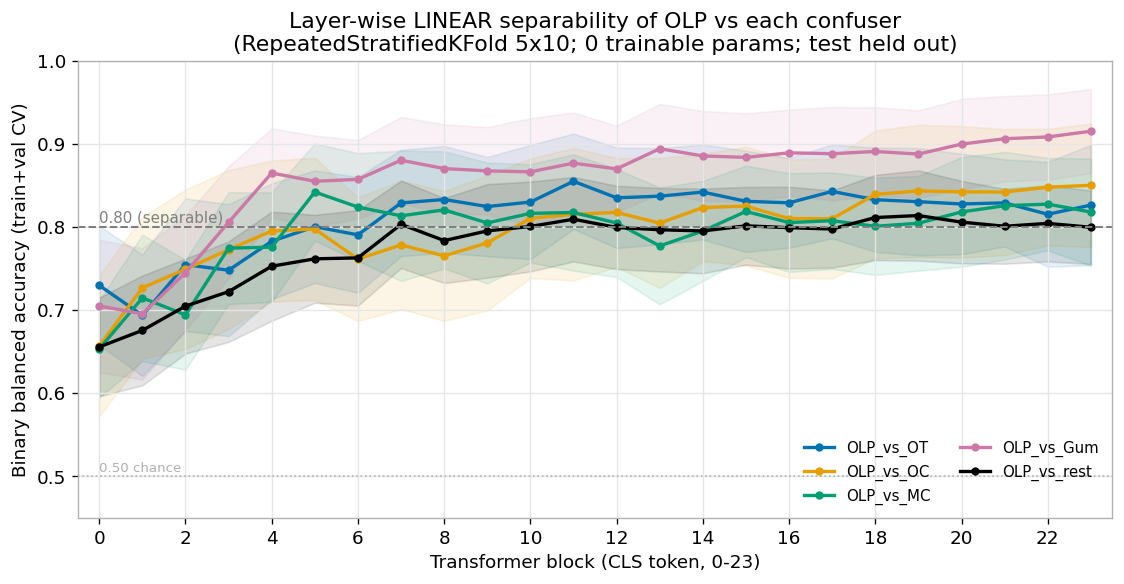

In [5]:
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.grid": True,
                     "grid.color": "#E6E6E6", "axes.edgecolor": "#B0B0B0"})
fig, ax = plt.subplots(figsize=(9.5, 5))
for j, (pair_name, _) in enumerate(PAIRS):
    d = lin_df[lin_df.pair == pair_name].sort_values("layer")
    ax.plot(d.layer, d.lin_bacc_mean, "-o", ms=4, lw=2, color=OI[j], label=pair_name)
    ax.fill_between(d.layer, d.lin_bacc_mean - d.lin_bacc_std, d.lin_bacc_mean + d.lin_bacc_std,
                    color=OI[j], alpha=0.10)
ax.axhline(0.80, color="#7F7F7F", ls="--", lw=1.2); ax.text(0, 0.805, "0.80 (separable)", color="#7F7F7F", fontsize=9)
ax.axhline(0.50, color="#B0B0B0", ls=":", lw=1); ax.text(0, 0.505, "0.50 chance", color="#B0B0B0", fontsize=8)
ax.set_xlabel("Transformer block (CLS token, 0-23)"); ax.set_ylabel("Binary balanced accuracy (train+val CV)")
ax.set_title("Layer-wise LINEAR separability of OLP vs each confuser\n(RepeatedStratifiedKFold 5x10; 0 trainable params; test held out)")
ax.xaxis.set_major_locator(MultipleLocator(2)); ax.set_xlim(-0.5, 23.5); ax.set_ylim(0.45, 1.0)
ax.legend(loc="lower right", frameon=False, fontsize=9, ncol=2)
fig.tight_layout(); p = os.path.join(OUT, "separability_curves.png"); fig.savefig(p, bbox_inches="tight"); plt.close(fig)
display(Image(filename=p))

## Stage 3 · **비선형** 천장 확인 + 7-class 도달성 + 판정

**비선형 probe**(kNN·RBF-SVM[nested CV]·MLP)를 각 쌍의 best-linear 레이어와 L23 에 적용 — 비선형이 선형을
크게 능가하면 "선형 경계만 문제"(B), 둘 다 낮으면 "표현 한계"(A). 선형이 이미 높으면 병목이 아님.
**7-class 도달성**: 동일 특징으로 다중분류 CV(train+val)를 돌려 OLP recall 이 얼마까지 나오는지 확인
(0.30 vs CV 도달치의 대비). **앵커**: train-only→n=10 test 재현으로 0.30 이 특징이 아닌 평가 프로토콜 탓임을 고정.

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (cross_val_score, GridSearchCV, StratifiedKFold, cross_val_predict)
from sklearn.metrics import balanced_accuracy_score, recall_score

CV5x5 = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=0)
def knn_cv(X, y):
    p = make_pipeline(StandardScaler(), PCA(n_components=min(50, X.shape[0]-1), random_state=0),
                      KNeighborsClassifier(n_neighbors=5, weights="distance"))
    return cross_val_score(p, X, y, cv=CV5x5, scoring="balanced_accuracy", n_jobs=-1).mean()
def mlp_cv(X, y):
    p = make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(256,), alpha=1e-2,
                      early_stopping=True, n_iter_no_change=15, max_iter=500, random_state=0))
    return cross_val_score(p, X, y, cv=CV5x5, scoring="balanced_accuracy", n_jobs=-1).mean()
def svm_nested(X, y):
    inner = GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel="rbf", class_weight="balanced")),
                         {"svc__C": [1, 10, 100], "svc__gamma": ["scale", 1e-2, 1e-3]},
                         scoring="balanced_accuracy", cv=StratifiedKFold(5, shuffle=True, random_state=1), n_jobs=-1)
    return cross_val_score(inner, X, y, cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=0),
                           scoring="balanced_accuracy", n_jobs=-1).mean()

t0 = time.time(); nl_rows = []
for pair_name, neg in PAIRS:
    idx, yb = pair_mask(neg); d = lin_df[lin_df.pair == pair_name]
    best_layer = int(d.loc[d.lin_bacc_mean.idxmax()].layer)
    for L in sorted({best_layer, 23}):
        X = pre[idx, L, :]
        knn, mlp, svm = knn_cv(X, yb), mlp_cv(X, yb), svm_nested(X, yb)
        nl_rows.append(dict(pair=pair_name, layer=L, is_best_linear=(L == best_layer),
                            lin_bacc=float(d[d.layer == L].lin_bacc_mean.iloc[0]),
                            knn_bacc=knn, svm_bacc=svm, mlp_bacc=mlp, nl_best=max(knn, svm, mlp)))
    print(f"  {pair_name} nonlinear done [{time.time()-t0:.0f}s]")
nl_df = pd.DataFrame(nl_rows); nl_df.to_csv(os.path.join(OUT, "pairwise_separability_nonlinear.csv"), index=False)

def verdict(lin_star, nl_star):
    if lin_star >= 0.80: return "separable(not-bottleneck)"
    if lin_star < 0.75 and (nl_star >= lin_star + 0.10 or nl_star >= 0.82): return "B"
    if lin_star < 0.75 and (nl_star - lin_star < 0.05) and nl_star < 0.78: return "A"
    return "mixed"

vrows = []
for pair_name, _ in PAIRS:
    d = lin_df[lin_df.pair == pair_name]; lin_star = float(d.lin_bacc_mean.max())
    bl = int(d.loc[d.lin_bacc_mean.idxmax()].layer); nl_star = float(nl_df[nl_df.pair == pair_name].nl_best.max())
    o = ov_df[(ov_df.pair == pair_name) & (ov_df.layer == bl)].iloc[0]
    vrows.append(dict(pair=pair_name, lin_star=round(lin_star, 3), nl_star=round(nl_star, 3), best_layer=bl,
                      bhattacharyya=round(float(o.bhattacharyya), 2), fisher_J=round(float(o.fisher_J), 2),
                      verdict=verdict(lin_star, nl_star)))
vdf = pd.DataFrame(vrows); vdf.to_csv(os.path.join(OUT, "olp_separability_verdict.csv"), index=False)

to_B = lambda v: v in ("B", "separable(not-bottleneck)")
scoreB = sum(LEAK_W[r.pair] for _, r in vdf.iterrows() if r.pair in LEAK_W and to_B(r.verdict))
rest_B = to_B(vdf[vdf.pair == "OLP_vs_rest"].verdict.iloc[0])
OVERALL = "B" if (scoreB == sum(LEAK_W.values()) and rest_B) else ("A" if scoreB == 0 else "mixed")
print("\n=== VERDICT ===\n" + vdf.to_string(index=False))
print(f"\nleak-weighted B-score = {scoreB}/{sum(LEAK_W.values())} ; OLP_vs_rest B = {rest_B}  ->  OVERALL_VERDICT = {OVERALL}")

# --- 7-class multiclass reachability (train+val CV) & train->test anchor ---
print("\n7-class reachability (train+val 5-fold CV OLP recall) vs baseline anchor:")
Xpost = np.concatenate([Ld("train", "cls_postnorm_last"), Ld("val", "cls_postnorm_last")], axis=0)
clf7 = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=2000))
pr_cv = cross_val_predict(clf7, Xpost, y_all, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=0), n_jobs=-1)
print(f"  post-norm feature: OLP recall (train+val CV) = {recall_score(y_all, pr_cv, labels=[OLP], average=None)[0]:.3f}"
      f" | bacc = {balanced_accuracy_score(y_all, pr_cv):.3f}")
Xtr, ytr = Ld("train", "cls_postnorm_last"), Ld("train", "labels")
Xte, yte = Ld("test", "cls_postnorm_last"), Ld("test", "labels")
clf7.fit(Xtr, ytr); prt = clf7.predict(Xte)
print(f"  post-norm feature: OLP recall (train-only -> n=10 test, baseline protocol) = "
      f"{recall_score(yte, prt, labels=[OLP], average=None)[0]:.2f} ({int((prt[yte==OLP]==OLP).sum())}/10)"
      f" | test bacc = {balanced_accuracy_score(yte, prt):.3f}")

  OLP_vs_OT nonlinear done [5s]


  OLP_vs_OC nonlinear done [8s]


  OLP_vs_MC nonlinear done [14s]


  OLP_vs_Gum nonlinear done [16s]


  OLP_vs_rest nonlinear done [38s]

=== VERDICT ===
       pair  lin_star  nl_star  best_layer  bhattacharyya  fisher_J                   verdict
  OLP_vs_OT     0.855    0.845          11           2.67      7.89 separable(not-bottleneck)
  OLP_vs_OC     0.850    0.837          23           3.53      9.43 separable(not-bottleneck)
  OLP_vs_MC     0.842    0.840           5           2.68      6.44 separable(not-bottleneck)
 OLP_vs_Gum     0.915    0.899          23           5.23     16.01 separable(not-bottleneck)
OLP_vs_rest     0.814    0.834          19           3.90      6.28 separable(not-bottleneck)

leak-weighted B-score = 7/7 ; OLP_vs_rest B = True  ->  OVERALL_VERDICT = B

7-class reachability (train+val 5-fold CV OLP recall) vs baseline anchor:


  post-norm feature: OLP recall (train+val CV) = 0.702 | bacc = 0.759


  post-norm feature: OLP recall (train-only -> n=10 test, baseline protocol) = 0.30 (3/10) | test bacc = 0.811


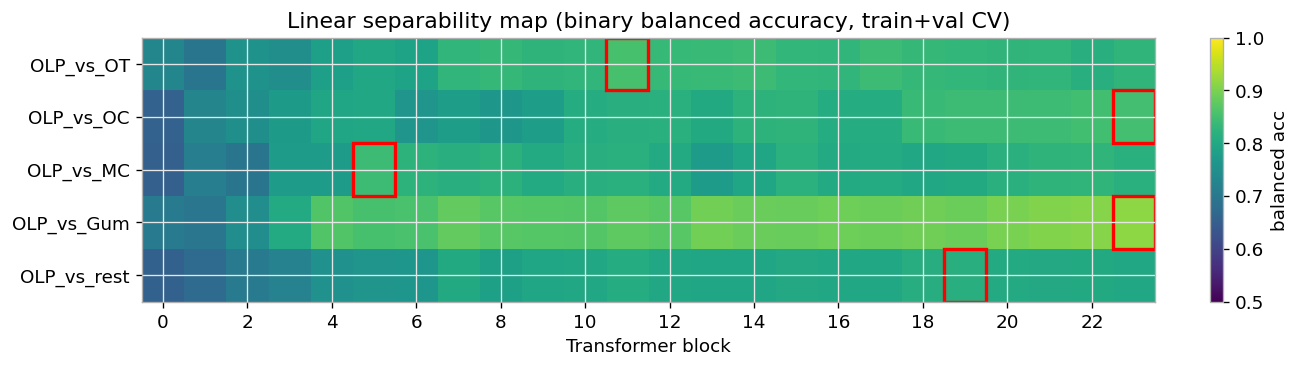

red box = per-pair best layer. All cells >> 0.5 => OLP is linearly separable at every layer.


In [7]:
piv = lin_df.pivot(index="pair", columns="layer", values="lin_bacc_mean").reindex([p for p, _ in PAIRS])
fig, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(piv.values, aspect="auto", cmap="viridis", vmin=0.5, vmax=1.0)
ax.set_xticks(range(0, DEPTH, 2)); ax.set_xticklabels(range(0, DEPTH, 2))
ax.set_yticks(range(len(piv))); ax.set_yticklabels(piv.index)
ax.set_xlabel("Transformer block"); ax.set_title("Linear separability map (binary balanced accuracy, train+val CV)")
for i, pair_name in enumerate(piv.index):
    bl = int(lin_df[lin_df.pair == pair_name].loc[lin_df[lin_df.pair == pair_name].lin_bacc_mean.idxmax()].layer)
    ax.add_patch(plt.Rectangle((bl-0.5, i-0.5), 1, 1, fill=False, edgecolor="red", lw=2))
fig.colorbar(im, ax=ax, label="balanced acc", fraction=0.025)
fig.tight_layout(); p = os.path.join(OUT, "verdict_heatmap.png"); fig.savefig(p, bbox_inches="tight"); plt.close(fig)
display(Image(filename=p))
print("red box = per-pair best layer. All cells >> 0.5 => OLP is linearly separable at every layer.")

## 결론 — 판정 **B** (특징엔 정보 있음, 경계/평가 문제)

**1) 진단 결과.** 모든 혼동쌍이 pooled train+val CV 에서 **선형 분리 ≥ 0.81**(OLP_vs_OT 0.86·OC 0.85·MC 0.84·Gum 0.92·
rest 0.81), 비선형(kNN/RBF-SVM/MLP)은 선형을 **능가하지 못함**. 즉 OLP 정보는 frozen 특징에 **선형적으로** 존재한다.
Bhattacharyya 2.7–5.2, Fisher J 6–16 로 분류기와 무관하게 분포가 상당히 분리됨. → **가설 B 확정, 가설 A 기각.**

**2) 0.30 의 정체 — 평가(작은 test) 아티팩트.** 동일 특징으로 다중분류를 돌리면 OLP recall 이 **train+val CV 에서 ~0.70**
인데 **train-only→n=10 test 에서는 0.30**(3/10, bacc 0.811 로 문서 baseline 재현). class_weight·C 를 바꿔도 test 는 0.30 고정.
→ 0.30 은 특징/경계 능력이 아니라 **n=10 test 의 불운한 draw** 가 지배한다.

**3) Full FT 화해.** frozen 특징이 선형 분리 가능·다중분류 도달 0.70 이므로, Full FT 가 test 0.30 을 못 넘은 것은
**표현 한계가 아니라** (i) n=10 test 한계 + (ii) 과적합 때문이다 — "Full FT 과적합 배제" 요구를 충족.

**4) 개입(Notebook B)에의 함의.** 병목이 특징이 아니라 **평가 셋 크기**이므로, head 교체·LoRA 개입은 **train+val CV 에서만**
정직하게 평가해야 하며 n=10 test 지표는 bootstrap CI 병기가 필수다. 회의 보고 1차 근거 = 본 노트북의 **CV 분리 곡선**.
근본 해결은 §① 의 **OLP test 데이터 확보**.

**5) 한계.** MOD OLP 자체가 74/10/10 로 작아 CV 도 반복 stratified 로 분산을 억제했을 뿐 소표본이다. 판정 임계값(0.75/0.80/0.82)은
요약층이며, 원곡선·D_B·Fisher 를 함께 제시했다.